In [1]:
import sys
import os

# 1. See the exact paths Python is searching for your modules
print("--- Python Import Paths ---")
for path in sys.path:
    print(path)

--- Python Import Paths ---
/home/theppawan/miniconda3/envs/ml_env/lib/python314.zip
/home/theppawan/miniconda3/envs/ml_env/lib/python3.14
/home/theppawan/miniconda3/envs/ml_env/lib/python3.14/lib-dynload

/home/theppawan/miniconda3/envs/ml_env/lib/python3.14/site-packages
/home/theppawan/nn-models/source


In [2]:
# Setup
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

from utils.data_reader import load_and_prepare_time_series_data
from utils.trainer import Trainer
from models.baseline_models import LSTMModel, BiLSTMModel, GRUModel, BiGRUModel
from models.custom_models import MGSSMModel, MGSSMsModel, ExtendedMGSSMsModel

### Fetching Data

In [19]:
data_url = "https://storage.googleapis.com/covid19-open-data/v3/location/US.csv"

# Safely unpack the data reader results regardless of which version you have
results = load_and_prepare_time_series_data(
    filepath_or_url=data_url,
    target_column=['cumulative_confirmed'],
    date_column="date",
    seq_length=14,
    batch_size=64,
    train_split=0.8,
    fill_missing=True
)

train_loader, val_loader, val_dataset, scaler = results

Fetching data from: https://storage.googleapis.com/covid19-open-data/v3/location/US.csv
Sorting data chronologicall by column: date
Succesfully loaded 991 sequential data points.
Prepared Training batches: 13 | Validation batches: 3


### Setting Models

In [4]:
model_config_list = [
    LSTMModel(input_size=1, hidden_size=256, num_layers=1, output_size=1),
    BiLSTMModel(input_size=1, hidden_size=256, num_layers=1, output_size=1),
    GRUModel(input_size=1, hidden_size=128, num_layers=1, output_size=1),
    MGSSMModel(input_size=1, hidden_size=64, num_layers=1, output_size=1, gate_size=32),
    MGSSMsModel(input_size=1, hidden_size=64, num_layers=1, output_size=1, gate_size=32),
    ExtendedMGSSMsModel(input_size=1, hidden_size=64, num_layers=1, output_size=1, gate_size=32, p=2)
]

### Training Models

In [ ]:
model_trained = []
for model in model_config_list:
    print(f"Training model: {model.__class__.__name__}")
    trainer = Trainer(
        model=model,
        criterion=nn.MSELoss(),
        optimizer=optim.Adam(model.parameters(), lr=0.001),
        device="cpu"
    )
    trainer.train(train_loader=train_loader, val_loader=val_loader, epochs=1000, patience=50)

Training model: LSTMModel
Starting training on device: cpu


Training Model:   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping triggered after 37 epochs.
Training complete! Best validation loss: 0.0000. Model saved to checkpoints/best_LSTMModel.pth
Training model: BiLSTMModel
Starting training on device: cpu


Training Model:   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping triggered after 31 epochs.
Training complete! Best validation loss: 0.0000. Model saved to checkpoints/best_BiLSTMModel.pth
Training model: GRUModel
Starting training on device: cpu


...

Early stopping triggered after 27 epochs.
Training complete! Best validation loss: 0.0000. Model saved to checkpoints/best_MGSSMModel.pth
Training model: MGSSMsModel
Starting training on device: cpu


Training Model:   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping triggered after 80 epochs.
Training complete! Best validation loss: 0.0000. Model saved to checkpoints/best_MGSSMsModel.pth
Training model: ExtendedMGSSMsModel
Starting training on device: cpu


Training Model:   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping triggered after 37 epochs.
Training complete! Best validation loss: 0.0000. Model saved to checkpoints/best_ExtendedMGSSMsModel.pth


### Get Results

In [21]:
def plot_predictions(model, val_loader, scaler):
    model.eval()
    
    actuals = []
    predictions = []

    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            preds = model(batch_x)
            actuals.extend(batch_y.cpu().numpy().flatten())
            predictions.extend(preds.cpu().numpy().flatten())

    predictions = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))
    actuals = scaler.inverse_transform(np.array(actuals).reshape(-1, 1))
            
    # Plotting the validation data
    plt.figure(figsize=(12, 6))
    plt.plot(actuals, label="Actual COVID-19 Cases", color="blue")
    plt.plot(predictions, label="Model Predictions", color="red", linestyle="--")
    plt.title(f"{model.__class__.__name__} Forecasting on COVID-19 Open Data")
    plt.xlabel("Days")
    plt.ylabel("Cumulative Confirmed Cases")
    plt.legend()
    plt.grid(True)
    plt.show()

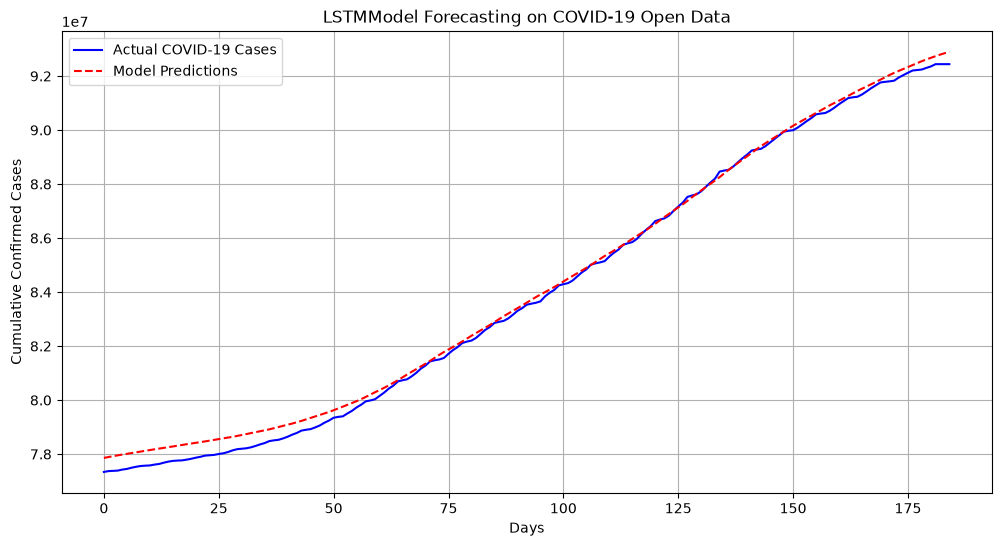

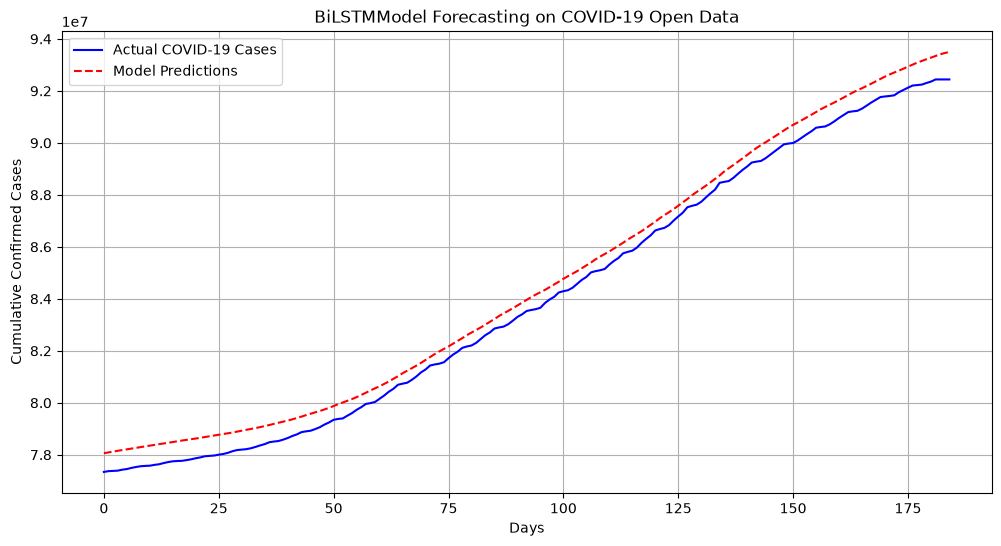

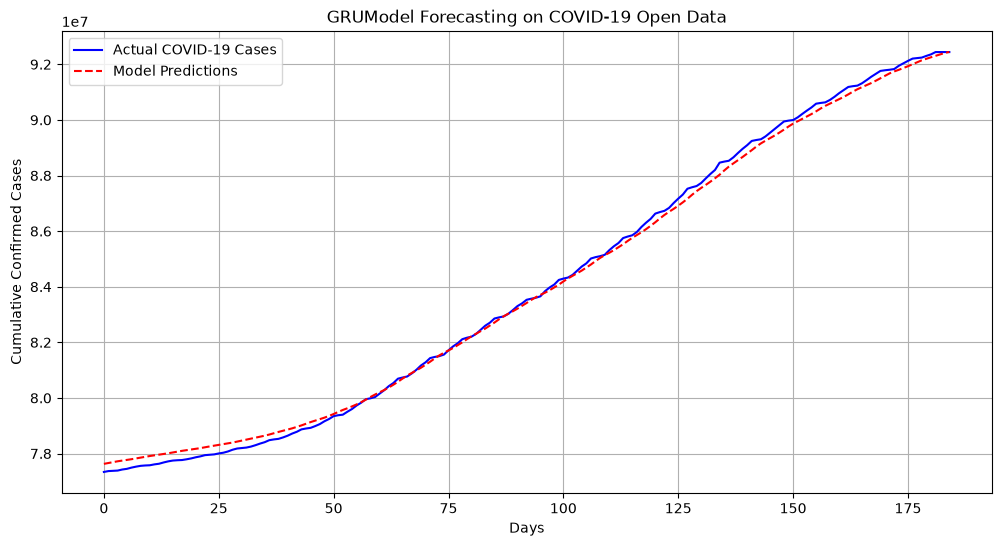

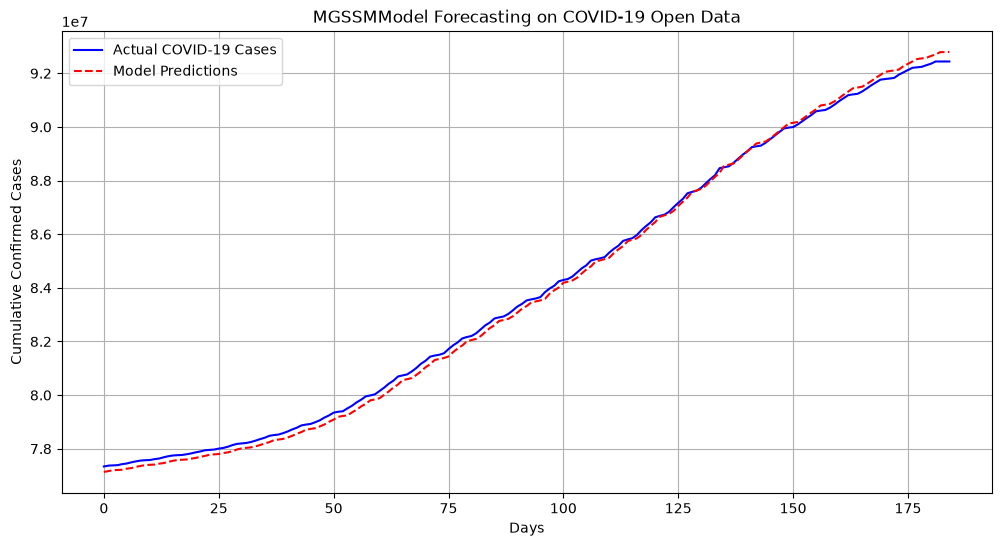

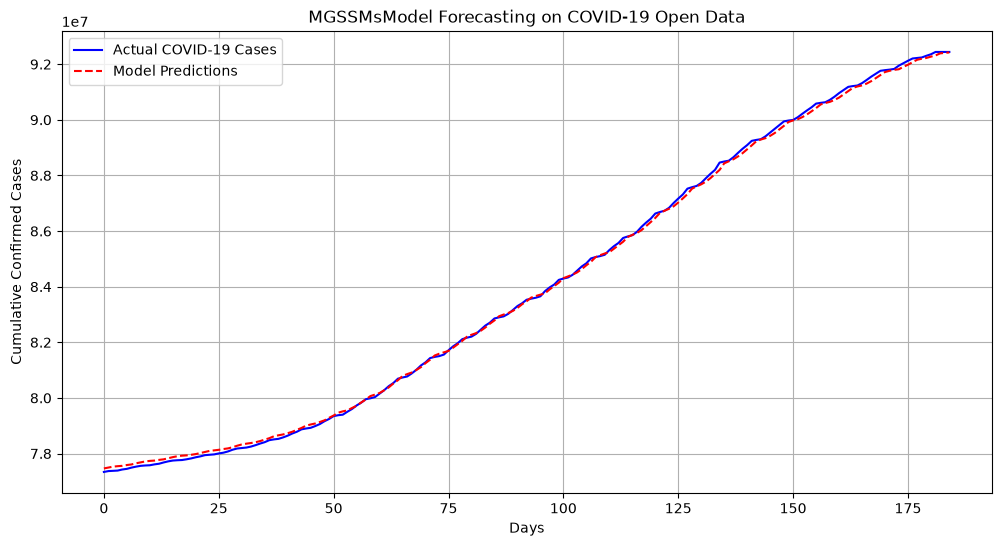

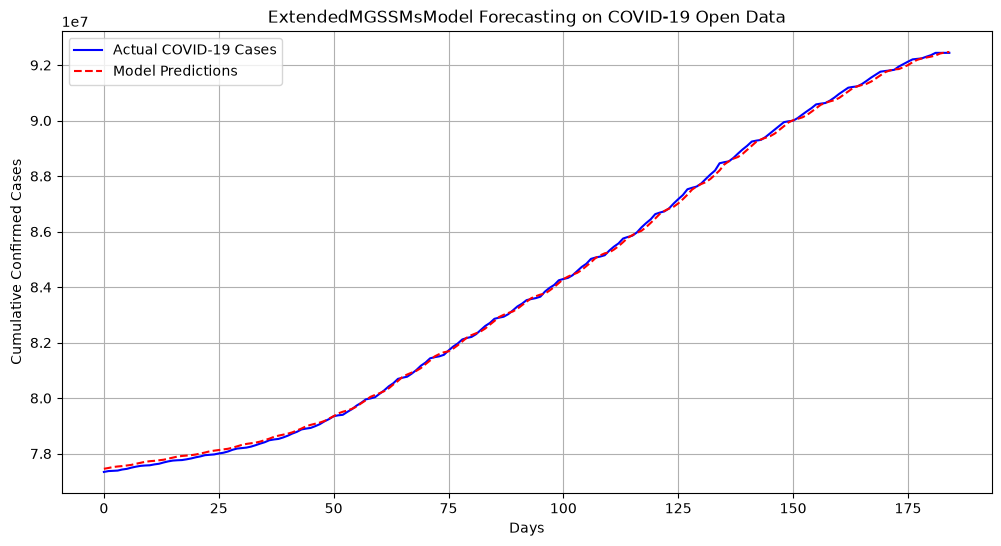

In [ ]:
for model_config in model_config_list:
    # analyze the model from the checkpoint
    model_config.load_state_dict(torch.load(f"checkpoints/best_{model_config.__class__.__name__}.pth"))
    plot_predictions(model_config, val_loader, scaler)